In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append("./src/nahiku")
from nahiku import Nahiku

# Create a Nahiku object from a (x, y) time series, inject an exocomet-shaped anomaly, and recover it using the Greedy Search method

### 1.) Create a simple sinusoid with noise

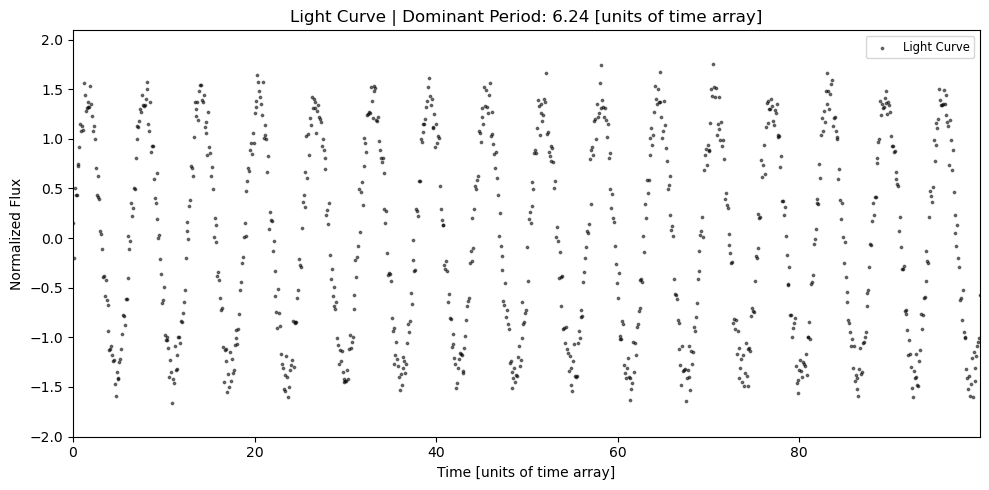

Light curve before prewhitening:


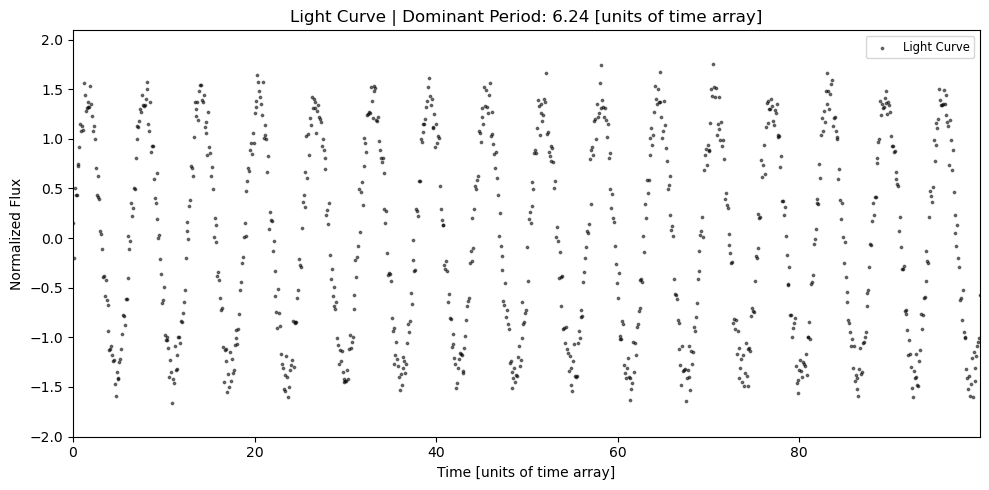

100%|██████████| 100/100 [00:00<00:00, 170.37it/s]
/mnt/lustre/koa/koastore/sadow_group/personal/linneamw/research/dipper_detection/nahiku/src/nahiku/nahiku.py:484: RuntimeWarning: divide by zero encountered in scalar divide
  periods = 1 / freqs_idx


No peaks found in power spectrum, using shoulder instead. Maximum dominant period is 99.90 days
Light curve after prewhitening:


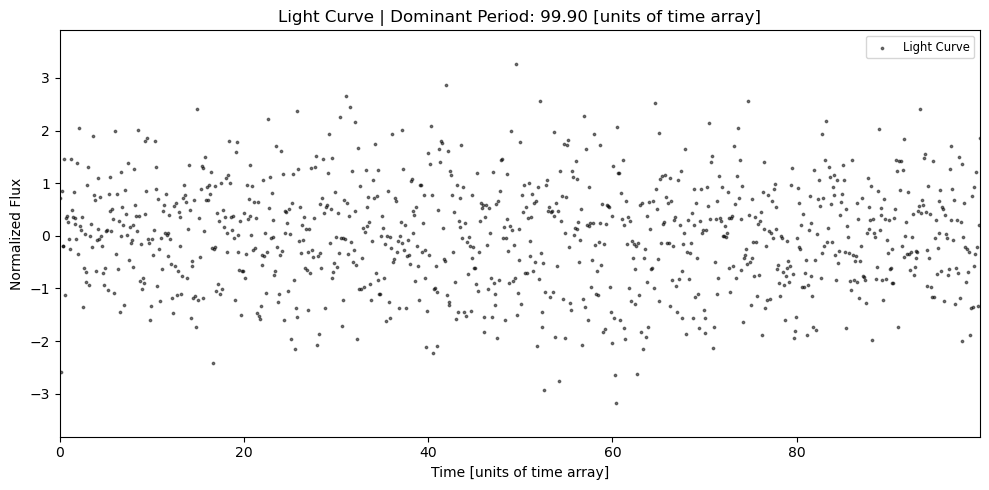

In [7]:
x = np.arange(0, 100, 0.1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

nahiku = Nahiku(x, y)
nahiku.plot()

# Prewhiten
nahiku.prewhiten(plot=True, minimum_snr=1)

### 2.) Inject an anomaly at index 350 with an exocomet shape, absolute width of 0.5 (in units of the time array), and absolute depth of 5 (in units of the flux array)

In [ ]:
anomaly_idxs, _, _, _ = nahiku.inject_anomaly(1, absolute_width=0.5, absolute_depth=5, shapes=["exocomet"], idxs=[350])
print(f"Current nahiku.anomalies dictionary: {nahiku.anomalies}")
nahiku.plot()

### 3.) Search for an injected anomaly using the greedy_search method, with plot=True to visualize the search process

In [ ]:
greedy_search = nahiku.greedy_search(plot=True)
print(f"Greedy search found {greedy_search.num_detected_anomalies} anomalous intervals.")
print(f"Current nahiku.anomalies dictionary: {nahiku.anomalies}")

### 4.) Plot and check whether the detected anomaly matches the injected anomaly

In [ ]:
nahiku.plot()
nahiku.check_identified_anomalies(buffer=10)

# Create a Nahiku object from a synthetic time series (sampled from a parameterized Gaussian Process), inject a gaussian-shaped anomaly, and recover it using the Exhaustive Search method

### 1.) Create a simple synthetic light curve from parameterized red and white noise, then a synthetic light curve by sampling from a Gaussian Process with a Quasi-Periodic kernel

/mnt/lustre/koa/koastore/sadow_group/personal/linneamw/research/dipper_detection/nahiku/src/nahiku/nahiku.py:500: UserWarning: Data is not standardized, and will be standardized for estimating the dominant period.
  warnings.warn("Data is not standardized, and will be standardized for estimating the dominant period.")


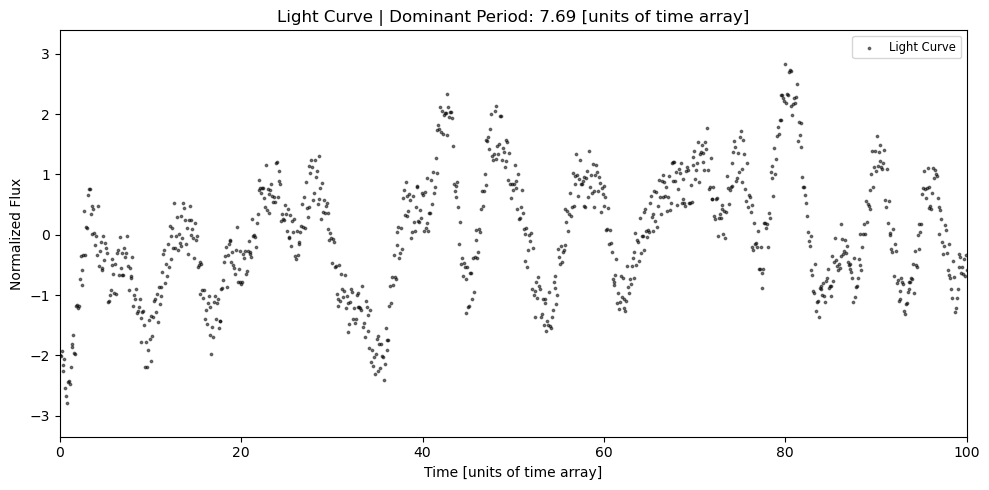

Light curve before prewhitening:


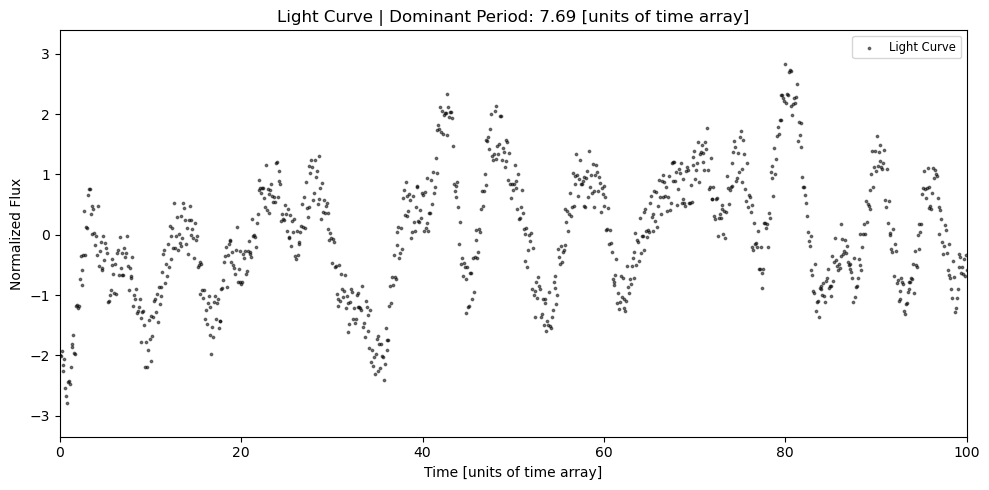

100%|██████████| 500/500 [00:03<00:00, 157.76it/s]


Light curve after prewhitening:


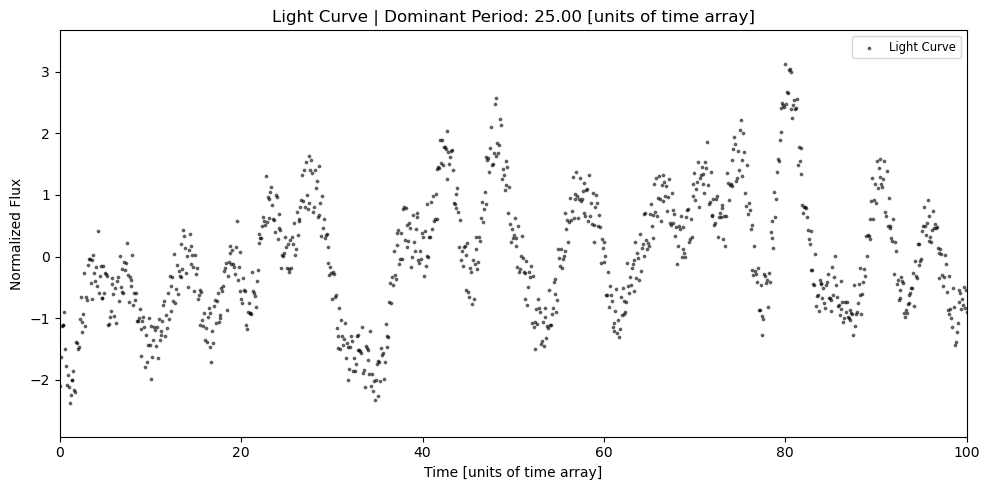

In [ ]:
# Synthetic light curve from parameterized noise values
nahiku = Nahiku.from_synthetic_parameterized_noise(num_steps=1000)
nahiku.plot()

/mnt/lustre/koa/koastore/sadow_group/personal/linneamw/research/dipper_detection/nahiku/src/nahiku/nahiku.py:500: UserWarning: Data is not standardized, and will be standardized for estimating the dominant period.
  warnings.warn("Data is not standardized, and will be standardized for estimating the dominant period.")


Light curve before prewhitening:


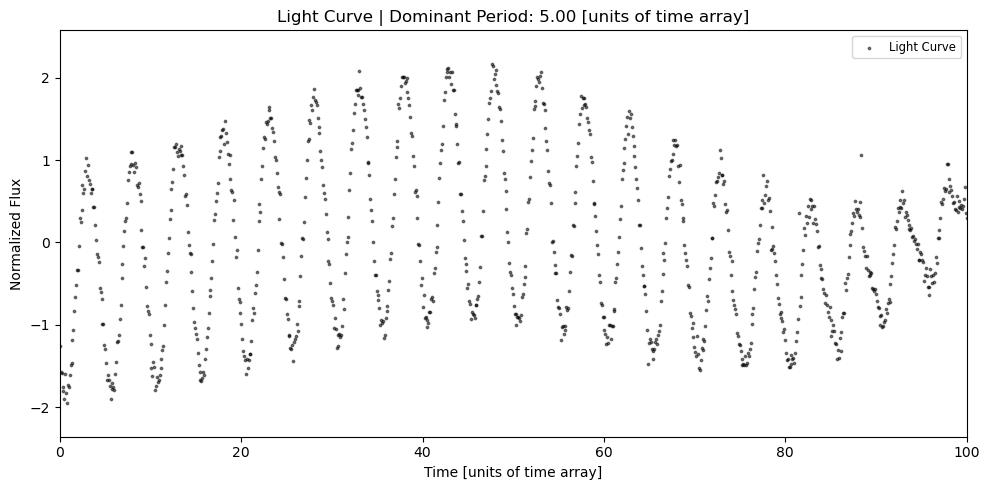

100%|██████████| 500/500 [00:03<00:00, 164.78it/s]


Light curve after prewhitening:


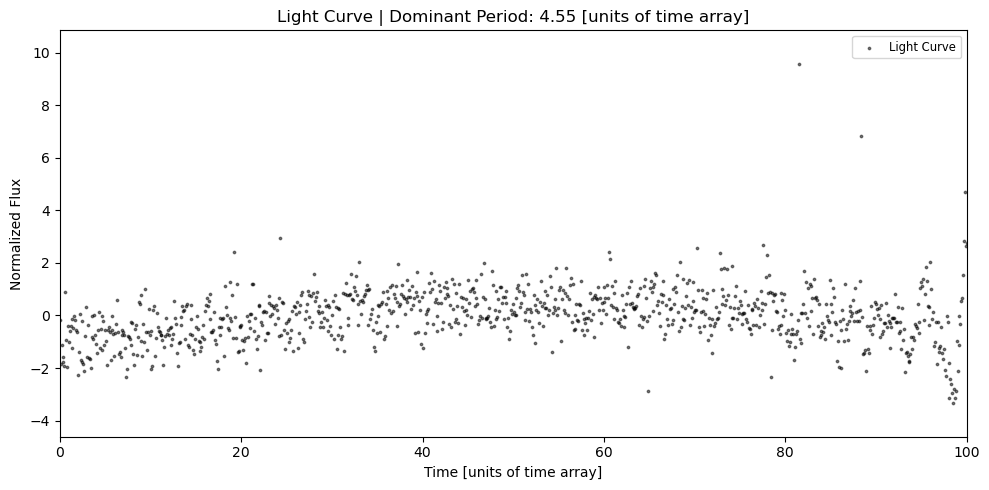

In [17]:
# Synthetic light curve from a GP
nahiku = Nahiku.from_synthetic_parameterized_gp(num_days=100, num_steps=1000, period=5, noise_std=0.1, add_high_residuals=True, num_high_residuals=5)

# Prewhiten
nahiku.prewhiten(plot=True, minimum_snr=0, maxiter=500)

### 2.) Inject an anomaly at index 200 with a gaussian shape, absolute width of 1 (in units of the time array), and absolute depth of 3 (in units of the flux array)

Injected gaussian-shaped anomaly with amplitude -6.00, width 2.00, and FWHM 4.71 at index 210 (time 21.02 [units of time array])
Current nahiku.anomalies dictionary: {'true': [], 'injected': [210], 'identified': []}


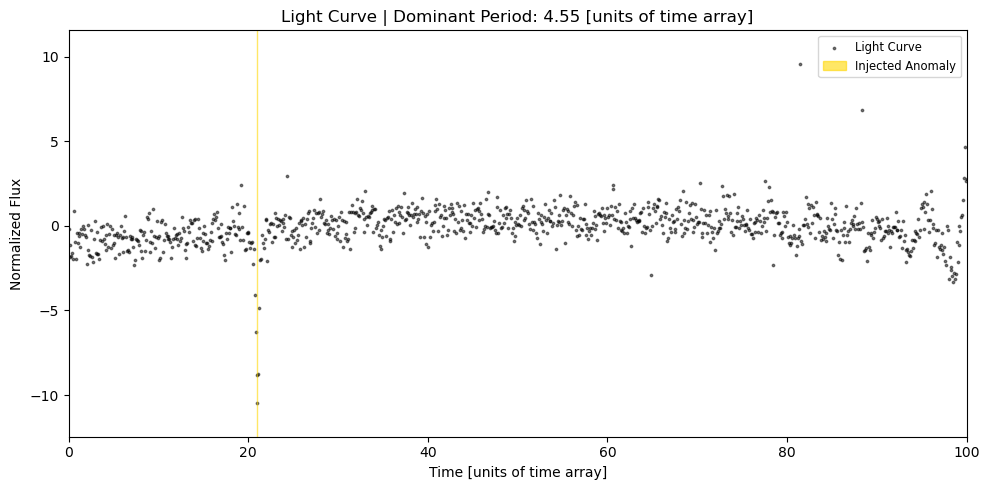

In [19]:
anomaly_idxs, _, _, _ = nahiku.inject_anomaly(1, absolute_width=2, absolute_depth=6, shapes=["gaussian"], idxs=[210])
print(f"Current nahiku.anomalies dictionary: {nahiku.anomalies}")
nahiku.plot()

### 3.) Search for an injected anomaly using the exhaustive_search method, with plot=True to visualize the search process

In [20]:
greedy_search = nahiku.exhaustive_search(plot=False, silent=False, min_anomaly_len=10, max_anomaly_len=100, window_slide_step=50, window_size_step=30, dynamic_programming=True)
print(f"Exhaustive search found {greedy_search.num_detected_anomalies} anomalous intervals.")
print(f"Current nahiku.anomalies dictionary: {nahiku.anomalies}")

Using 100 as minimum iterations for early stopping.
Early stopping at iteration 104 due to increasing train loss.
Anomaly interval: 0-10, metric pval over the interval: 0.3845990094311023, pos or neg: -1
Anomaly interval: 0-40, metric pval over the interval: 0.8883073463968478, pos or neg: -1
Anomaly interval: 0-70, metric pval over the interval: 0.9943755379342581, pos or neg: -1
Anomaly interval: 50-60, metric pval over the interval: 0.949657095749503, pos or neg: 1
Anomaly interval: 50-90, metric pval over the interval: 0.9880313699177333, pos or neg: 1
Anomaly interval: 50-120, metric pval over the interval: 0.9213353345222252, pos or neg: -1
Anomaly interval: 100-110, metric pval over the interval: 0.5469207367324769, pos or neg: -1
Anomaly interval: 100-140, metric pval over the interval: 0.7784797211092886, pos or neg: -1
Anomaly interval: 100-170, metric pval over the interval: 0.02639767804660815, pos or neg: 1
Anomaly interval: 150-160, metric pval over the interval: 0.936680

### 4.) Plot and check whether the detected anomaly matches the injected anomaly

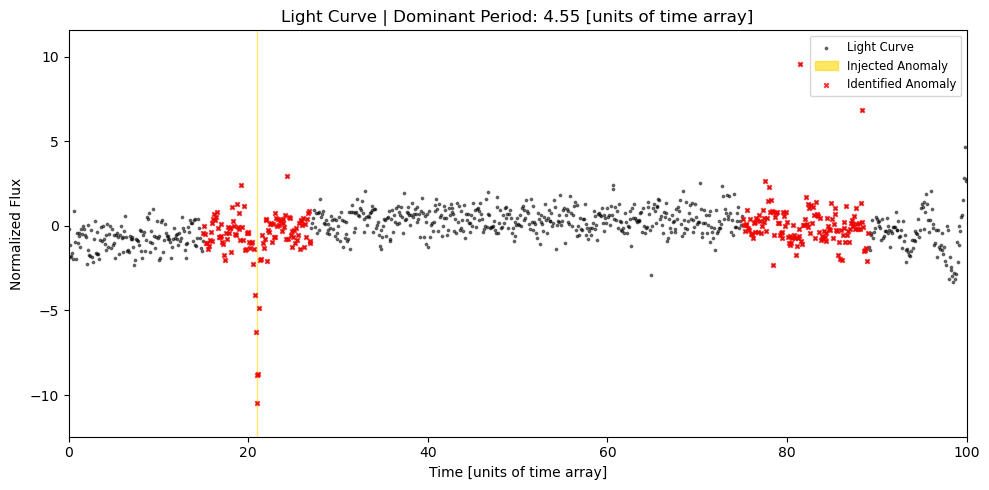

Events Detected: 1 / 1
Event-wise TPR: 1.00
False Positive Events: 1
Event-wise Precision: 0.50


{'tpr': 1.0, 'precision': 0.5, 'detected_count': 1, 'false_positives': 1}

In [21]:
nahiku.plot()
nahiku.check_identified_anomalies(buffer=10)